In [3]:
import torch
from torch import nn, optim
from torchvision import datasets, transforms
from keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import copy
import time
from torch.utils.data import Dataset, DataLoader,TensorDataset
import random

In [4]:
# Data Loading and Preprocessing

# Load the MNIST dataset
(x_train_full, y_train_full), (x_test, y_test) = mnist.load_data()

# Normalization: Convert pixel values from [0, 255] to [0, 1] for better convergence
x_train_full = x_train_full.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Flattening: Convert 28x28 images into one-dimensional vectors of size 784
# Required for the MLP
x_train_full = x_train_full.reshape((-1, 784))
x_test = x_test.reshape((-1, 784))

# Split the training set into Train (80%) and Validation (20%)
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full, test_size=0.2, random_state=42
)


# Define a custom dataset with dynamic mapping
class DynamicNextDigitDataset(Dataset):
    def __init__(self, x_data, y_data):
        """
        Dataset initialization.
        Creates buckets for each digit so that random targets can be found quickly.
        """
        # Convert to PyTorch tensors once for efficiency
        self.x_data = torch.tensor(x_data, dtype=torch.float32)

        # Check and convert the labels
        if not torch.is_tensor(y_data):
            self.y_data = torch.tensor(y_data, dtype=torch.long)
        else:
            self.y_data = y_data.long()

        # Create an index structure (buckets):
        # buckets[0] -> contains all indexes of images labeled as '0'
        # buckets[1] -> contains all indexes of images labeled as '1', etc.
        self.buckets = {i: [] for i in range(10)}
        for idx, label in enumerate(self.y_data):
            self.buckets[label.item()].append(idx)

    def __getitem__(self, index):

        # 1. Get the input image and its label
        img_input = self.x_data[index]
        label_input = self.y_data[index]

        # 2. Compute the target label
        # The formula (label + 1 + 10) % 10 gives the next digit cyclically
        label_target = (label_input + 1 + 10) % 10

        # 3. Randomly select a target image
        # Instead of using fixed pairs, we randomly select an image from the target bucket.
        # This acts as data augmentation and prevents memorization.
        random_target_idx = random.choice(self.buckets[label_target.item()])
        img_target = self.x_data[random_target_idx]

        return img_input, img_target, label_input, label_target

    def __len__(self):
        # Return the total dataset size
        return len(self.x_data)

# Create the new datasets using dynamic mapping
train_ds = DynamicNextDigitDataset(x_train, y_train)
val_ds = DynamicNextDigitDataset(x_val, y_val)
test_ds = DynamicNextDigitDataset(x_test, y_test)

batch_size = 256

# Create DataLoaders
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

In [5]:
class DigitTransformerAE(nn.Module):
    def __init__(self):
        super(DigitTransformerAE, self).__init__()

        # Encoder: deep and wide
        # 784 -> 1024 -> 512 -> 128 (Bottleneck)
        self.encoder = nn.Sequential(
            nn.Linear(784, 1024),
            nn.ReLU(),
            nn.Dropout(0.2),      # Regularization

            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.2),      # Regularization

            nn.Linear(512, 128)   # Bottleneck (large enough to preserve detail)
        )

        # Decoder: symmetric, without dropout for cleaner images
        # 128 -> 512 -> 1024 -> 784
        self.decoder = nn.Sequential(
            nn.Linear(128, 512),
            nn.ReLU(),

            nn.Linear(512, 1024),
            nn.ReLU(),

            nn.Linear(1024, 784),
            nn.Sigmoid()          # Required for BCE
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded


In [6]:
# Training parameters
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DigitTransformerAE().to(device)
# criterion = nn.MSELoss()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.1)

In [7]:
# Training settings
epochs = 50
patience = 8 # Early Stopping patience
best_loss = float('inf')
counter = 0
best_model = None

train_losses, val_losses = [], []
train_accs, val_accs = [], []

# Training timer
total_start_time = time.time()

for epoch in range(epochs):
    epoch_start_time = time.time()

    model.train()
    running_loss = 0.0
    running_acc = 0.0

    for inputs, targets, _, _ in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        # Forward
        outputs = model(inputs)
        loss = criterion(outputs, targets)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()


    # Epoch statistics
    train_loss = running_loss / len(train_loader)

    #VALIDATION
    model.eval()
    val_running_loss = 0.0

    with torch.no_grad():

        for inputs, targets, _, _ in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            outputs = model(inputs)

            # Validation Loss
            loss = criterion(outputs, targets)
            val_running_loss += loss.item()

    # Epoch statistics (Validation)
    val_loss = val_running_loss / len(val_loader)
    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # Compute epoch time
    epoch_duration = time.time() - epoch_start_time

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Time: {epoch_duration:.2f}s")

    #EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"⏹️ Early stopping at epoch {epoch+1}! Best Val Loss: {best_loss:.4f}")
            break

total_training_time = time.time() - total_start_time

# Load the best model
if best_model:
    model.load_state_dict(best_model)

print("✅ Training finished!")
print(f"⏱️ Total Training Time: {total_training_time:.2f} seconds")

Epoch [1/50] | Train Loss: 0.2722 | Val Loss: 0.2476 | Time: 3.87s
Epoch [2/50] | Train Loss: 0.2355 | Val Loss: 0.2295 | Time: 3.72s
Epoch [3/50] | Train Loss: 0.2284 | Val Loss: 0.2276 | Time: 3.32s
Epoch [4/50] | Train Loss: 0.2279 | Val Loss: 0.2264 | Time: 3.26s
Epoch [5/50] | Train Loss: 0.2268 | Val Loss: 0.2264 | Time: 2.80s
Epoch [6/50] | Train Loss: 0.2264 | Val Loss: 0.2260 | Time: 4.56s
Epoch [7/50] | Train Loss: 0.2260 | Val Loss: 0.2253 | Time: 2.62s
Epoch [8/50] | Train Loss: 0.2256 | Val Loss: 0.2262 | Time: 3.91s
Epoch [9/50] | Train Loss: 0.2253 | Val Loss: 0.2250 | Time: 5.46s
Epoch [10/50] | Train Loss: 0.2256 | Val Loss: 0.2258 | Time: 2.89s
Epoch [11/50] | Train Loss: 0.2257 | Val Loss: 0.2256 | Time: 2.51s
Epoch [12/50] | Train Loss: 0.2251 | Val Loss: 0.2249 | Time: 2.53s
Epoch [13/50] | Train Loss: 0.2249 | Val Loss: 0.2245 | Time: 2.87s
Epoch [14/50] | Train Loss: 0.2253 | Val Loss: 0.2255 | Time: 3.00s
Epoch [15/50] | Train Loss: 0.2249 | Val Loss: 0.2254 | T

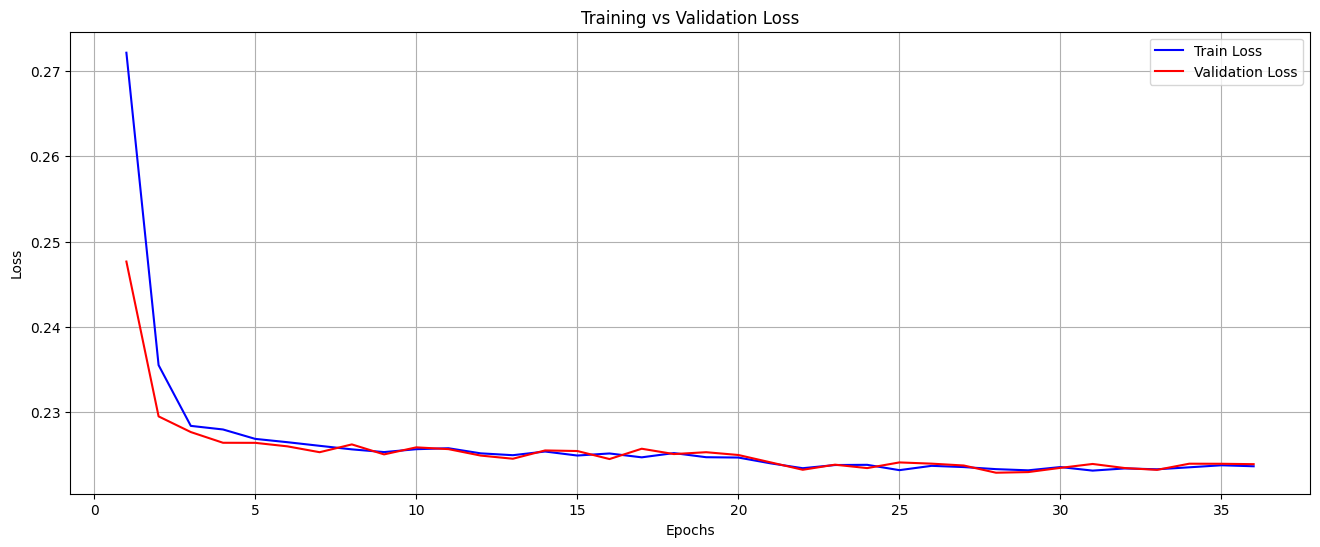

In [8]:
# Training curve
epochs_range = range(1, len(train_losses) + 1)
plt.figure(figsize=(16, 6))
plt.plot(epochs_range, train_losses, 'b-', label='Train Loss')
plt.plot(epochs_range, val_losses, 'r-', label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


# Define the CNN classifier
class CNNclassifier(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        # BLOCK 1: Input (1) -> 32 Filters
        # Image size: 28x28 -> 14x14
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25)
        )

        # BLOCK 2: 32 -> 64 Filters
        # Image size: 14x14 -> 7x7
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25)
        )

        # CLASSIFIER
        # Flatten size: 64 channels * 7 * 7 pixels = 3136
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.5), # More aggressive dropout to reduce overfitting
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.classifier(x)
        return x


In [10]:
# SETTINGS & DATA for the Judge
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

print("🚀 Preparing data for the Judge...")
mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
mnist_test = datasets.MNIST(root='./data', train=False, download=True, transform=transforms.ToTensor())

clf_train_loader = DataLoader(mnist_train, batch_size=128, shuffle=True)
clf_test_loader = DataLoader(mnist_test, batch_size=128, shuffle=False)

clf_model = CNNclassifier().to(device)
clf_optimizer = optim.Adam(clf_model.parameters(), lr=0.001)
clf_criterion = nn.CrossEntropyLoss()


print("🚀 Training the CNN Judge...")

# CNN TRAINING
epochs = 5
for epoch in range(epochs):

    clf_model.train()
    train_loss = 0.0
    correct_train = 0
    total_train = 0

    for imgs, labels in clf_train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        clf_optimizer.zero_grad()
        outputs = clf_model(imgs)
        loss = clf_criterion(outputs, labels)
        loss.backward()
        clf_optimizer.step()

        train_loss += loss.item()

        # Compute training accuracy
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    avg_train_loss = train_loss / len(clf_train_loader)
    train_acc = 100 * correct_train / total_train

    #VALIDATION
    clf_model.eval()
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for imgs, labels in clf_test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = clf_model(imgs)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_acc = 100 * correct_val / total_val

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Acc: {val_acc:.2f}%")

print("\n✅ The Judge has been trained.")
print(f"🏆 Final Accuracy on the Test Set: {val_acc:.2f}%")

Using device: cuda
🚀 Preparing data for the Judge...


100%|██████████| 9.91M/9.91M [00:01<00:00, 4.97MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.22MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.52MB/s]


🚀 Training the CNN Judge...
Epoch [1/5] | Train Loss: 0.3024 | Train Acc: 90.56% | Val Acc: 98.22%
Epoch [2/5] | Train Loss: 0.1268 | Train Acc: 96.21% | Val Acc: 98.62%
Epoch [3/5] | Train Loss: 0.1063 | Train Acc: 96.75% | Val Acc: 98.77%
Epoch [4/5] | Train Loss: 0.0885 | Train Acc: 97.39% | Val Acc: 99.03%
Epoch [5/5] | Train Loss: 0.0813 | Train Acc: 97.56% | Val Acc: 99.11%

✅ The Judge has been trained.
🏆 Final Accuracy on the Test Set: 99.11%



📊 VALIDATION EVALUATION (Checking progress without cheating)...
⏳ Calculating Judge Accuracy on Validation Set...
🎯 JUDGE ACCURACY ON VALIDATION DATA: 97.97%

🖼️ Visualizing Random Batch from Validation Set...


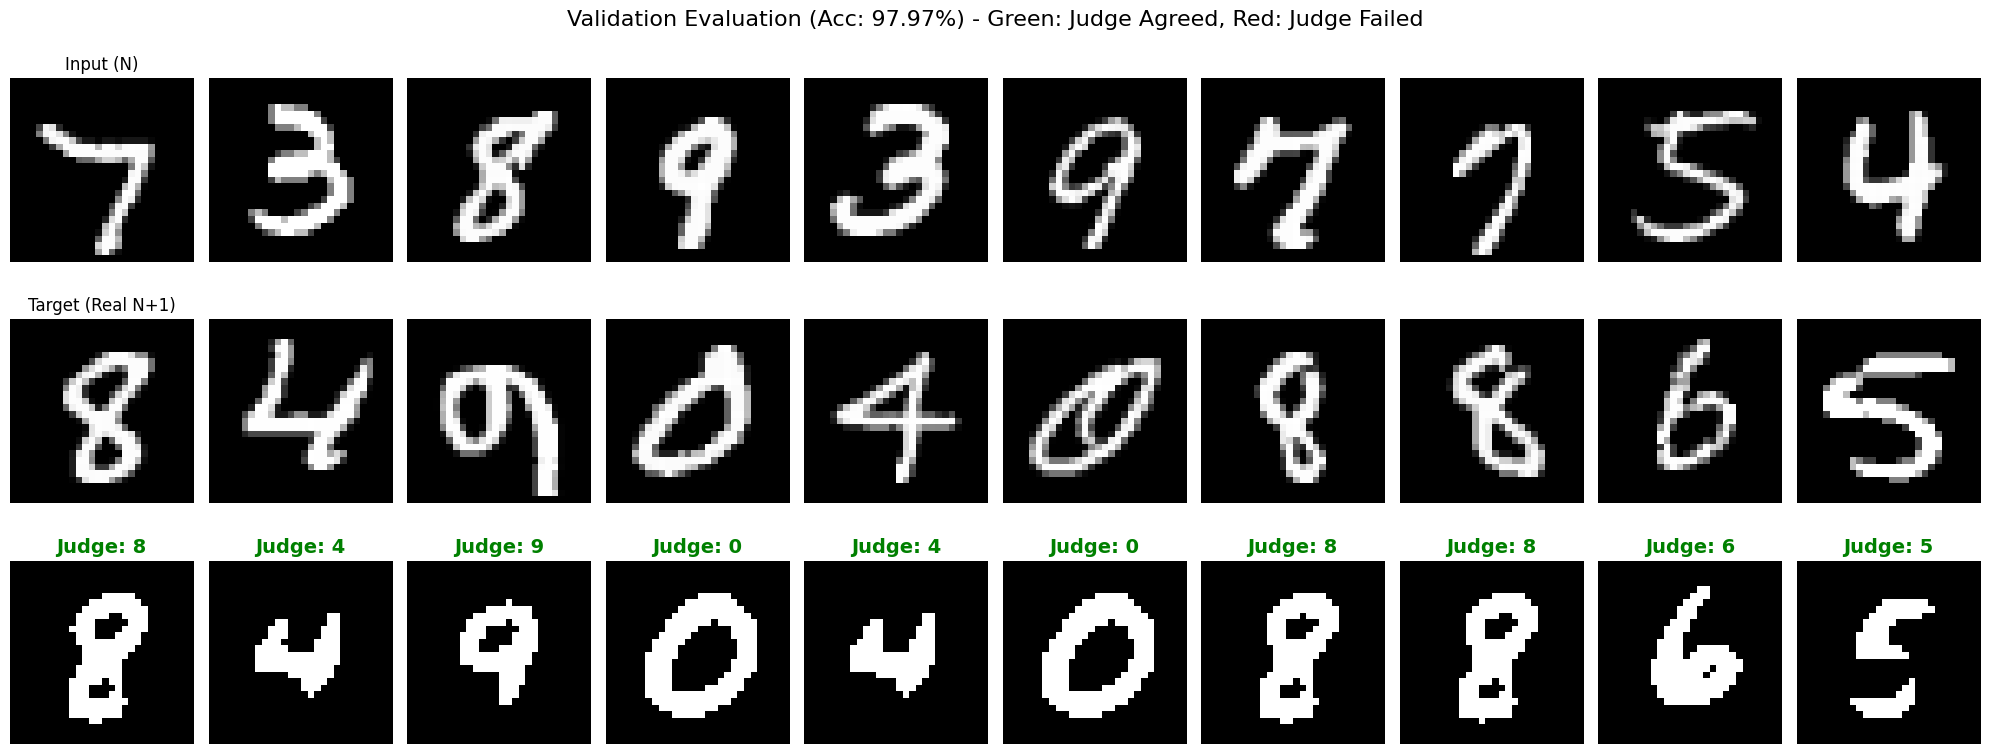

In [11]:
# Validation loss and examples of correct/incorrect predictions

print("\n📊 VALIDATION EVALUATION (Checking progress without cheating)...")

model.eval()
clf_model.eval()

threshold = 0.4

correct = 0
total = 0

print("⏳ Calculating Judge Accuracy on Validation Set...")

with torch.no_grad():

    for inputs, _, _, target_labels in val_loader:
        inputs = inputs.to(device)
        target_labels = target_labels.to(device)

        # 1. Generate Images
        inputs_flat = inputs.view(inputs.size(0), -1)
        generated_flat = model(inputs_flat)

        # Reshape into image format
        generated_imgs = generated_flat.view(inputs.size(0), 1, 28, 28)
        generated_imgs = (generated_imgs > threshold).float() # Thresholding

        # 3. Judge Prediction
        outputs = clf_model(generated_imgs)
        _, predicted = torch.max(outputs, 1)

        total += target_labels.size(0)
        correct += (predicted == target_labels).sum().item()

val_accuracy = 100 * correct / total
print(f"🎯 JUDGE ACCURACY ON VALIDATION DATA: {val_accuracy:.2f}%")


print("\n🖼️ Visualizing Random Batch from Validation Set...")
n = 10

with torch.no_grad():
    # Get a random batch from the validation loader
    inputs, targets, _, target_labels = next(iter(val_loader))

    inputs = inputs.to(device)
    target_labels = target_labels.to(device)

    # Generate
    inputs_flat = inputs.view(inputs.size(0), -1)
    generated_flat = model(inputs_flat)

    # Process
    generated_imgs = generated_flat.view(inputs.size(0), 1, 28, 28)
    generated_imgs = (generated_imgs > threshold).float() # Thresholding

    # Judge prediction for the plot
    pred_outputs = clf_model(generated_imgs)
    _, pred_labels = torch.max(pred_outputs, 1)

    inputs = inputs.cpu()
    targets = targets.cpu()
    generated_imgs = generated_imgs.cpu()
    pred_labels = pred_labels.cpu()
    target_labels = target_labels.cpu()

    # Plot
    plt.figure(figsize=(20, 8))
    plt.suptitle(f"Validation Evaluation (Acc: {val_accuracy:.2f}%) - Green: Judge Agreed, Red: Judge Failed", fontsize=16)

    for i in range(n):
        # 1. Input
        ax = plt.subplot(3, n, i + 1)
        plt.imshow(inputs[i].reshape(28, 28), cmap='gray')
        ax.axis('off')
        if i == 0: ax.set_title("Input (N)", fontsize=12)

        # 2. Real Target
        ax = plt.subplot(3, n, i + 1 + n)
        plt.imshow(targets[i].reshape(28, 28), cmap='gray')
        ax.axis('off')
        if i == 0: ax.set_title("Target (Real N+1)", fontsize=12)

        # 3. Generated
        ax = plt.subplot(3, n, i + 1 + 2*n)
        plt.imshow(generated_imgs[i].reshape(28, 28), cmap='gray')
        ax.axis('off')

        judge_pred = pred_labels[i].item()
        real_label = target_labels[i].item()
        col = 'green' if judge_pred == real_label else 'red'

        ax.set_title(f"Judge: {judge_pred}", color=col, fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

🎯 JUDGE ACCURACY ON ALL TEST DATA: 98.01%

🖼️ Visualizing Random Batch...


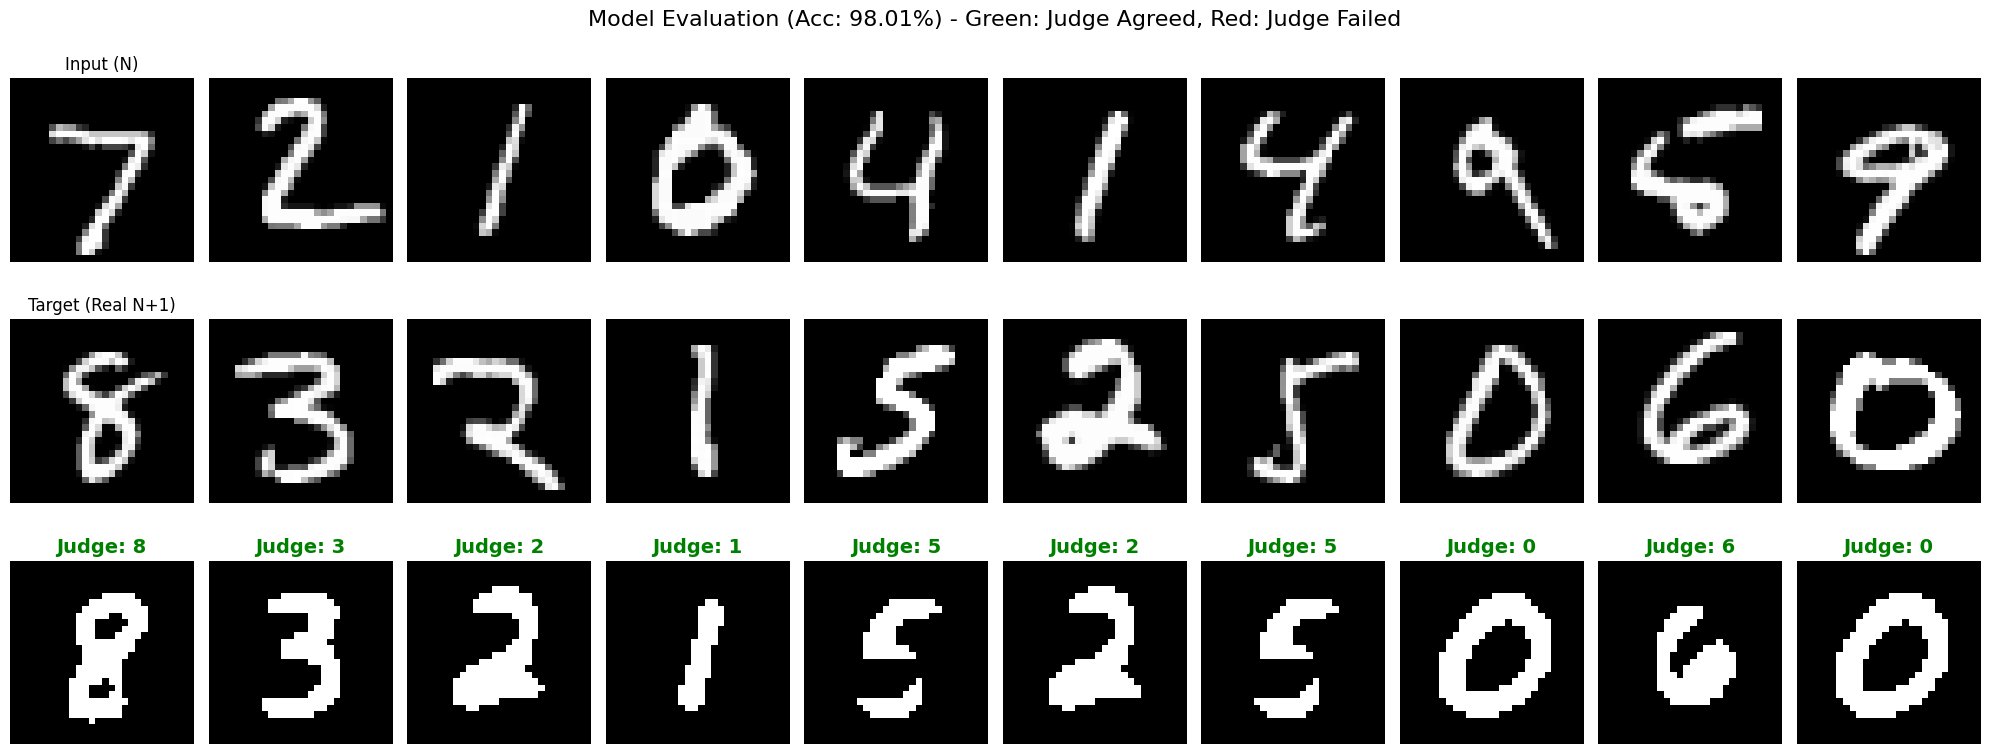

In [12]:
# Same procedure for the test set

model.eval()
clf_model.eval()
threshold = 0.4

correct = 0
total = 0

with torch.no_grad():
    for inputs, _, _, target_labels in test_loader:
        inputs = inputs.to(device)
        target_labels = target_labels.to(device)

        inputs_flat = inputs.view(inputs.size(0), -1)
        generated_flat = model(inputs_flat)

        generated_imgs = generated_flat.view(inputs.size(0), 1, 28, 28)
        generated_imgs = (generated_imgs > threshold).float() # Thresholding

        outputs = clf_model(generated_imgs)
        _, predicted = torch.max(outputs, 1)

        total += target_labels.size(0)
        correct += (predicted == target_labels).sum().item()

final_accuracy = 100 * correct / total
print(f"🎯 JUDGE ACCURACY ON ALL TEST DATA: {final_accuracy:.2f}%")

print("\n🖼️ Visualizing Random Batch...")
n = 10

with torch.no_grad():

    inputs, targets, _, target_labels = next(iter(test_loader))

    inputs = inputs.to(device)
    target_labels = target_labels.to(device)

    inputs_flat = inputs.view(inputs.size(0), -1)
    generated_flat = model(inputs_flat)

    generated_imgs = generated_flat.view(inputs.size(0), 1, 28, 28)
    generated_imgs = (generated_imgs > threshold).float()

    pred_outputs = clf_model(generated_imgs)
    _, pred_labels = torch.max(pred_outputs, 1)

    inputs = inputs.cpu()
    targets = targets.cpu()
    generated_imgs = generated_imgs.cpu()
    pred_labels = pred_labels.cpu()
    target_labels = target_labels.cpu()

    plt.figure(figsize=(20, 8))
    plt.suptitle(f"Model Evaluation (Acc: {final_accuracy:.2f}%) - Green: Judge Agreed, Red: Judge Failed", fontsize=16)

    for i in range(n):

        ax = plt.subplot(3, n, i + 1)
        plt.imshow(inputs[i].reshape(28, 28), cmap='gray')
        ax.axis('off')
        if i == 0: ax.set_title("Input (N)", fontsize=12)

        ax = plt.subplot(3, n, i + 1 + n)
        plt.imshow(targets[i].reshape(28, 28), cmap='gray')
        ax.axis('off')
        if i == 0: ax.set_title("Target (Real N+1)", fontsize=12)

        ax = plt.subplot(3, n, i + 1 + 2*n)
        plt.imshow(generated_imgs[i].reshape(28, 28), cmap='gray')
        ax.axis('off')

        judge_pred = pred_labels[i].item()
        real_label = target_labels[i].item()
        col = 'green' if judge_pred == real_label else 'red'

        ax.set_title(f"Judge: {judge_pred}", color=col, fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

🚀 Preparing test data (targets)...
   Total Test Images: 10000

🔄 Running PCA (n_components=16)...
   -> Accuracy with PCA-16: 87.29%

🔄 Running PCA (n_components=64)...
   -> Accuracy with PCA-64: 98.12%

🔄 Running PCA (n_components=128)...
   -> Accuracy with PCA-128: 98.66%


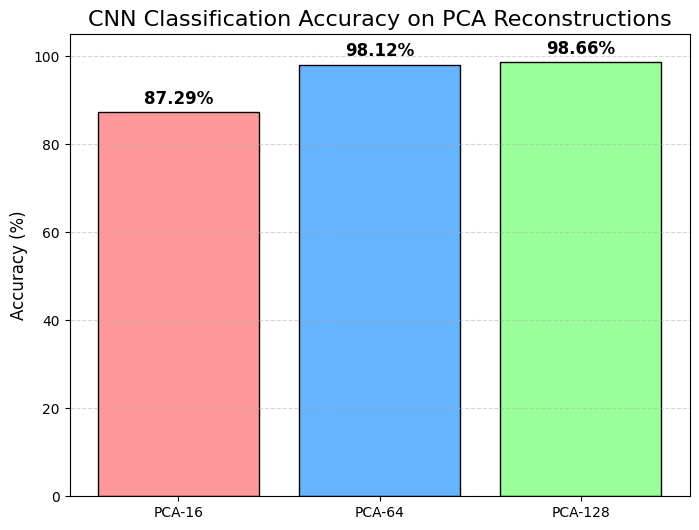

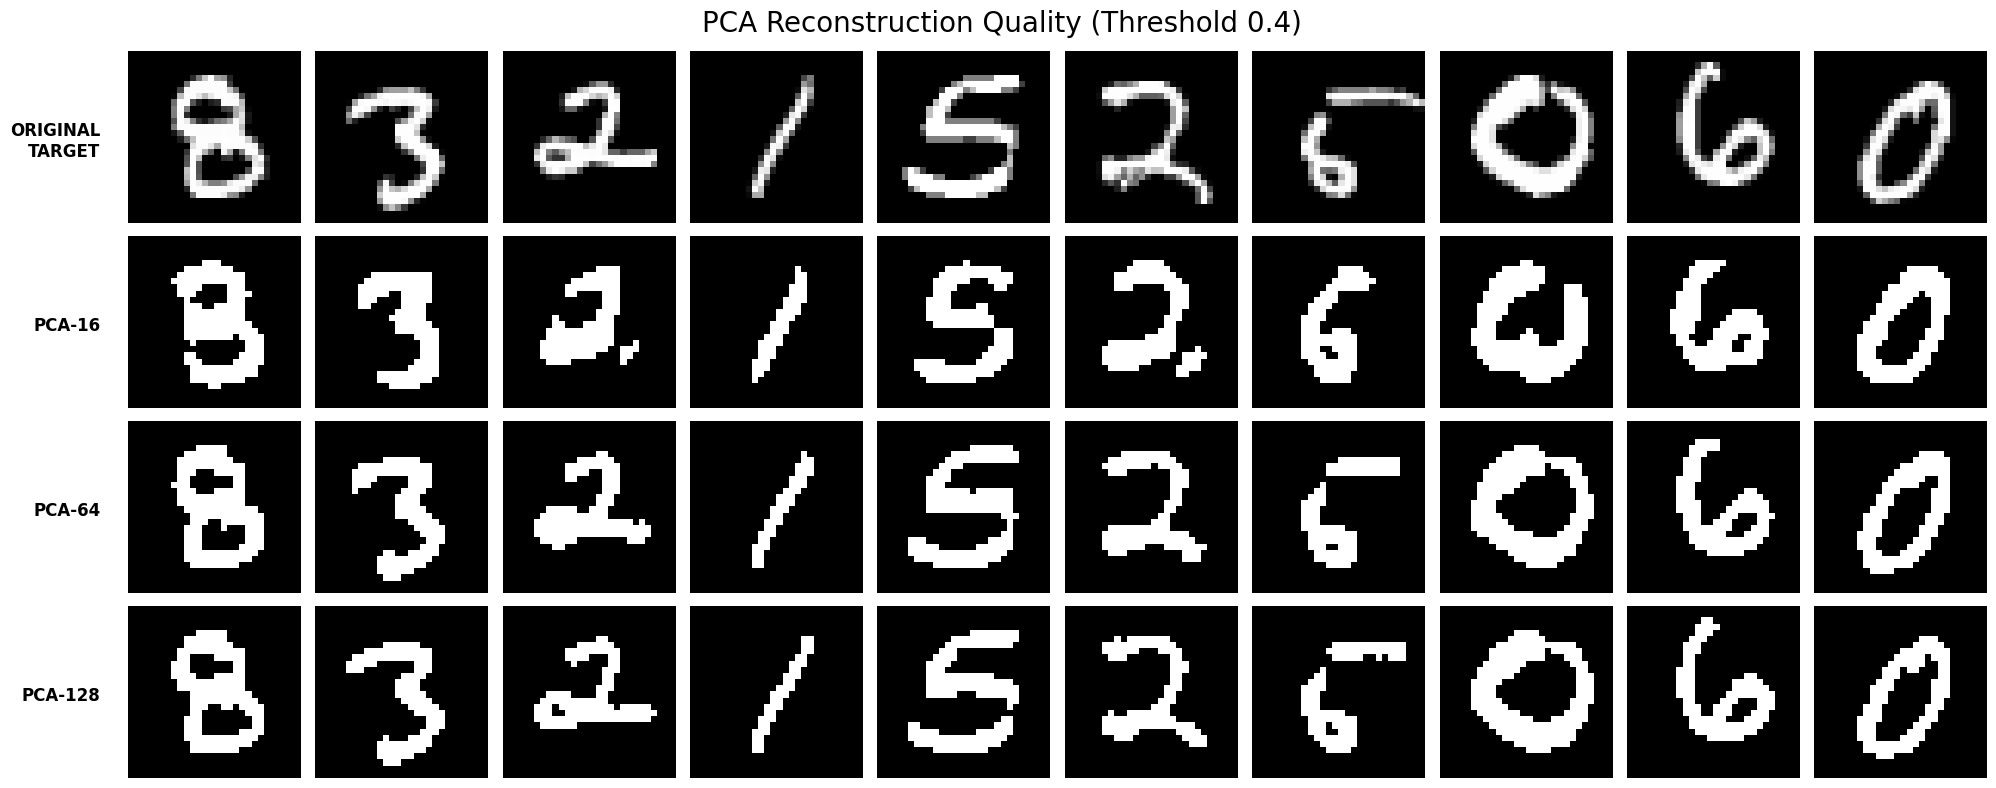

In [15]:
# PCA visualization
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from torch.utils.data import DataLoader, TensorDataset


threshold = 0.4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
clf_model.eval()

n_components_list = [16, 64, 128]
pca_results = {}

print("🚀 Preparing test data (targets)...")

all_targets = []
all_labels = []

for _, targets, _, target_labels in test_loader:
    all_targets.append(targets)
    all_labels.append(target_labels)

all_targets_tensor = torch.cat(all_targets, dim=0)
all_labels_tensor = torch.cat(all_labels, dim=0)

X_test = all_targets_tensor.view(all_targets_tensor.size(0), -1).numpy()
y_test = all_labels_tensor.to(device)

print(f"   Total Test Images: {X_test.shape[0]}")

for n in n_components_list:
    print(f"\n🔄 Running PCA (n_components={n})...")

    pca = PCA(n_components=n)
    X_compressed = pca.fit_transform(X_test)
    X_reconstructed = pca.inverse_transform(X_compressed)


    recon_tensor = torch.tensor(X_reconstructed, dtype=torch.float32)
    recon_imgs = recon_tensor.view(-1, 1, 28, 28)

    recon_imgs = (recon_imgs > threshold).float()


    temp_dataset = TensorDataset(recon_imgs, all_labels_tensor)
    temp_loader = DataLoader(temp_dataset, batch_size=1000, shuffle=False)

    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, lbls in temp_loader:
            imgs = imgs.to(device)
            lbls = lbls.to(device)

            outputs = clf_model(imgs)
            _, predicted = torch.max(outputs, 1)

            total += lbls.size(0)
            correct += (predicted == lbls).sum().item()

    accuracy = 100 * correct / total
    print(f"   -> Accuracy with PCA-{n}: {accuracy:.2f}%")


    pca_results[n] = {
        "accuracy": accuracy,
        "sample_imgs": recon_imgs[:10]
    }

accuracies = [pca_results[n]["accuracy"] for n in n_components_list]
labels = [f"PCA-{n}" for n in n_components_list]
colors = ['#ff9999', '#66b3ff', '#99ff99']

plt.figure(figsize=(8, 6))
bars = plt.bar(labels, accuracies, color=colors, edgecolor='black')

# Add values on top
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.2f}%',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('CNN Classification Accuracy on PCA Reconstructions', fontsize=16)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.ylim(0, 105)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


n_samples = 10
original_imgs = all_targets_tensor[:n_samples]

plt.figure(figsize=(20, 8))
plt.suptitle(f"PCA Reconstruction Quality (Threshold {threshold})", fontsize=20, y=0.98)

for i in range(n_samples):
    ax = plt.subplot(4, n_samples, i + 1)
    plt.imshow(original_imgs[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
    if i == 0:
        ax.text(-5, 14, "ORIGINAL\nTARGET", fontsize=12, fontweight='bold', va='center', ha='right')

for idx, n in enumerate(n_components_list):
    recon_imgs = pca_results[n]["sample_imgs"]

    for i in range(n_samples):

        plot_idx = (idx + 1) * n_samples + (i + 1)

        ax = plt.subplot(4, n_samples, plot_idx)
        plt.imshow(recon_imgs[i].reshape(28, 28), cmap='gray')
        ax.axis('off')

        if i == 0:
            ax.text(-5, 14, f"PCA-{n}", fontsize=12, fontweight='bold', va='center', ha='right')

plt.tight_layout()
plt.show()

In [ ]:
# Visualization of experimental results: accuracy and loss bar plots
import matplotlib.pyplot as plt
import numpy as np

labels = [
    '(WD=0, LR=0.001)',
    '(WD=1e-5, LR=0.001)',
    '(WD=1e-4, LR=0.001)',
    '(WD=1e-5, LR=0.01)',
    '(WD=1e-5, LR=0.0005)'
]

acc = [97.26, 97.07, 91.95, 94.03, 96.87]
loss = [0.2236, 0.2238, 0.2271, 0.2272, 0.2240]

x_pos = np.arange(len(labels))

plt.figure(figsize=(9, 6))

bars1 = plt.bar(x_pos, acc, color='#4a90e2', edgecolor='black', alpha=0.8, width=0.6)

plt.xticks(x_pos, labels, rotation=15, ha='right', fontsize=10, fontweight='bold')
plt.ylabel('Validation Accuracy (%)', fontsize=12, fontweight='bold', color='#003366')
plt.title('Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylim(90, 98)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.1, f'{height:.2f}%',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))

bars2 = plt.bar(x_pos, loss, color='#ff7f50', edgecolor='black', alpha=0.8, width=0.6)

plt.xticks(x_pos, labels, rotation=15, ha='right', fontsize=10, fontweight='bold')
plt.ylabel('Validation Loss (BCE)', fontsize=12, fontweight='bold', color='#8b0000')
plt.title('Loss Comparison', fontsize=14, fontweight='bold')
plt.ylim(0.2230, 0.2280) # Zoom
plt.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.0001, f'{height:.4f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Comparison of PCA with different Autoencoder architectures
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

dimensions = ['16 Dimensions', '64 Dimensions', '128 Dimensions']

# Baseline (PCA)
pca_scores = [87.29, 98.12, 98.66]

# Autoencoders - Group 1
ae_scores_1 = [94.11, 97.38, 91.94]
ae_names_1  = ["2.Deep Narrow", "3.Deep Balanced", "1.Shallow"]

# Autoencoders - Group 2
ae_scores_2 = [0, 97.92, 97.97]
ae_names_2  = ["", "4.Deep Gradual Decrement", "5.Best (Wide)"]


x = np.arange(len(dimensions))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 8))


rects1 = ax.bar(x - width, pca_scores, width, label='PCA', color='#A9A9A9', edgecolor='black', alpha=0.9)


rects2 = ax.bar(x, ae_scores_1, width, label='AE Basic', color='#4a90e2', edgecolor='black', alpha=0.9)

valid_indices = [i for i, v in enumerate(ae_scores_2) if v > 0]
valid_scores = [ae_scores_2[i] for i in valid_indices]

valid_names = [ae_names_2[i] for i in valid_indices]

rects3 = ax.bar(x[valid_indices] + width, valid_scores, width, label='AE Advanced',
                color='#66b3ff', edgecolor='black', hatch='//', alpha=0.9)


def autolabel(rects, names, is_pca=False):
    """Adds the percentage above the bar and the model name inside the bar."""
    for idx, rect in enumerate(rects):
        height = rect.get_height()

        # 1. Percentage above the bar
        ax.annotate(f'{height}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=11, fontweight='bold')


        if not is_pca:

            name = names[idx]
            ax.annotate(name,
                        xy=(rect.get_x() + rect.get_width() / 2, height - 5),
                        xytext=(0, -10),
                        textcoords="offset points",
                        ha='center', va='top', fontsize=10, color='white', fontweight='bold', rotation=90)

autolabel(rects1, [], is_pca=True)
autolabel(rects2, ae_names_1)
autolabel(rects3, valid_names)


ax.set_ylabel('Accuracy (%)', fontsize=14, fontweight='bold')
ax.set_title('Accuracy Comparison: PCA vs Autoencoder Architectures', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(dimensions, fontsize=12, fontweight='bold')
ax.set_ylim(85, 100)
ax.grid(axis='y', linestyle='--', alpha=0.5)


legend_elements = [
    Patch(facecolor='#A9A9A9', edgecolor='black', label='PCA (Linear Baseline)'),
    Patch(facecolor='#4a90e2', edgecolor='black', label='Autoencoder (Basic Configs)'),
    Patch(facecolor='#66b3ff', edgecolor='black', hatch='//', label='Autoencoder (Advanced Configs)')
]
ax.legend(handles=legend_elements, loc='best', fontsize=12)

plt.tight_layout()
plt.show()